# LangGraph on LangChain p1

LangGraph is a low-level orchestration framework for building stateful workflows and agents. Instead of hiding the control flow inside a single chain, LangGraph makes the steps explicit through **nodes**, **edges**, and **shared state**.

This course is based on the [LangChain Academy material](https://github.com/langchain-ai/langchain-academy), the early modules build these ideas progressively with simple graphs, routers, agents, state schemas, reducers, and message-based memory. In this notebook, we will cover the core patterns you need before moving to larger workflows.

We will focus on:

1. State, nodes, edges, and compilation
2. Conditional routing
3. `MessagesState` and a tool-calling agent
4. Reducers for controlled state updates
5. Short-term memory with checkpointing


Useful references:

* LangGraph overview: https://docs.langchain.com/oss/python/langgraph/overview
* Thinking in LangGraph: https://docs.langchain.com/oss/python/langgraph/thinking-in-langgraph
* Graph API (state, nodes, edges, reducers, `MessagesState`): https://docs.langchain.com/oss/python/langgraph/graph-api
* Tavily search integration: https://docs.langchain.com/oss/python/integrations/tools/tavily_search
* LangChain Academy repository: https://github.com/langchain-ai/langchain-academy

In [ ]:
# !pip install python-dotenv langgraph langgraph-prebuilt langchain langchain-openai langchain-google-genai langchain-community langchain-openrouter langchain_nvidia_ai_endpoints langchain-tavily langsmith


In [ ]:
import getpass
import os

from dotenv import find_dotenv, load_dotenv

_ = load_dotenv(find_dotenv())

In [ ]:
from google.colab import userdata
import os

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = userdata.get('LANGCHAIN_API_KEY')
os.environ["LANGCHAIN_PROJECT"] = "LLM Class"

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langchain_openrouter import ChatOpenRouter
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from google.colab import userdata

def get_model_name(model_name, temperature=0):
    if model_name == "gemini": # https://ai.google.dev/gemini-api/docs/rate-limits?hl=pt-br
        if "GOOGLE_API_KEY" not in os.environ: # https://ai.google.dev/gemini-api/docs/api-key
            os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')
        llm = ChatGoogleGenerativeAI(
            # model="gemini-2.5-pro", # max 50 / dia
            model="gemini-2.5-flash", # max 1500 / dia
            temperature=temperature,
        )
    elif model_name == "openai":  # https://platform.openai.com
        if "OPENAI_API_KEY" not in os.environ:
            os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
        llm = ChatOpenAI(
            model="gpt-4o-mini",
            temperature=temperature,
        )
    elif model_name == "openrouter": # https://openrouter.ai/workspaces/default/
        if "OPENROUTER_API_KEY" not in os.environ:
            os.environ["OPENROUTER_API_KEY"] = userdata.get('OPENROUTER_API_KEY')

        llm = ChatOpenRouter(
            model="openrouter/free",
            api_key=os.environ["OPENROUTER_API_KEY"],
            temperature=temperature,
        )
    elif model_name == "nvidia": # https://build.nvidia.com/explore/discover
       if "NVIDIA_API_KEY" not in os.environ:
           os.environ["NVIDIA_API_KEY"] = userdata.get('NVIDIA_API_KEY')

       TOOL_MODELS = [ # May need to change the model to run the notebook
           "openai/gpt-oss-120b",
           "qwen/qwen3-next-80b-a3b-instruct",
           "nvidia/llama-3.1-nemotron-ultra-253b-v1",
       ]
       llm = ChatNVIDIA(
           model=TOOL_MODELS[0],
           api_key=os.environ["NVIDIA_API_KEY"],
           temperature=temperature,
       )

    return llm

llm = get_model_name('nvidia')
resp = llm.invoke("Olá")
print(resp.content)

Olá! Como posso ajudar você hoje?


In [ ]:
from IPython.display import Image, Markdown, display

from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_nvidia_ai_endpoints import ChatNVIDIA, NVIDIAEmbeddings

def _get_secret(name: str, prompt_text: str) -> str:
    if os.environ.get(name):
        return os.environ[name]
    if userdata is not None:
        try:
            value = userdata.get(name)
            if value:
                os.environ[name] = value
                return value
        except Exception:
            pass
    os.environ[name] = getpass.getpass(prompt_text)
    return os.environ[name]

def get_embeddings(provider="nvidia"):
    if provider == "google":
        _get_secret("GOOGLE_API_KEY", "Enter your Google AI API key: ")
        return GoogleGenerativeAIEmbeddings(model="models/embedding-001")
    if provider == "openai":
        _get_secret("OPENAI_API_KEY", "Enter your OpenAI API key: ")
        return OpenAIEmbeddings(model="text-embedding-3-large")
    if provider == "nvidia":
        _get_secret("NVIDIA_API_KEY", "Enter your NVIDIA API key: ")
        return NVIDIAEmbeddings(
            model="nvidia/nv-embed-v1",
            api_key=os.environ["NVIDIA_API_KEY"],
        )
    raise ValueError("provider must be 'google', 'openai', or 'nvidia'.")


def show_graph(graph):
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        mermaid = graph.get_graph().draw_mermaid()
        display(Markdown("```text\n" + mermaid + "\n```"))

embeddings = get_embeddings("nvidia")


# Section 10. Graph Fundamentals

The goal of this notebook is to make the basic pieces of LangGraph feel concrete before we move to larger systems.

We will start with the smallest graphs possible, inspect the shared state at each step, and only then add more behavior such as routing, tools, reducers, and memory. When it helps, we will contrast a simple chain with a graph so the difference in control flow is easier to see.


## 10.1 State and Nodes - [link](https://docs.langchain.com/oss/python/langgraph/overview)

The smallest useful LangGraph example has three parts:

1. a state schema
2. one or more nodes that read from and write to that state
3. edges that decide the execution order

In this first graph, each node returns only a partial state update. LangGraph applies that update to the shared state and passes the result forward.

What to notice as you run the next cells:

* the node functions do not mutate the full state in place
* edges describe control flow, not business logic
* `compile()` turns the builder into an executable graph and validates the structure


In [ ]:
from typing_extensions import TypedDict
import random

from langgraph.graph import END, START, StateGraph

class SimpleLessonState(TypedDict):
    topic: str
    response: str

def present_topic(state: SimpleLessonState):
    print("--- present_topic ---")
    return {"response": f"Today we will study {state['topic']}."}


def continue_sentence(state: SimpleLessonState):
    print("--- continue_sentence ---")
    choices = ["Learning is fun!", "You will enjoy!", "Nice!"]
    return {"response": state["response"] + f" {random.choice(choices)}"}


### Graph Definition

Now, lets define the graph. The code below is the moment where the abstract pieces become an executable graph.

* `StateGraph(SimpleLessonState)` creates a graph builder whose shared state follows `SimpleLessonState`.
* `add_node(...)` registers Python functions and gives each one a name that can be referenced by edges.
* `add_edge(START, "present_topic")` says which node receives the initial input.
* `add_edge("present_topic", "continue_sentence")` creates a fixed transition to the next node.
* `add_edge("continue_sentence", END)` marks the workflow as finished after that node runs.
* `compile()` validates the structure and returns a runnable graph object.

A good way to read it is:

`START -> present_topic -> continue_sentence -> END`

References:

* Graph API overview: https://docs.langchain.com/oss/python/langgraph/graph-api
* Use the Graph API: https://docs.langchain.com/oss/python/langgraph/use-graph-api


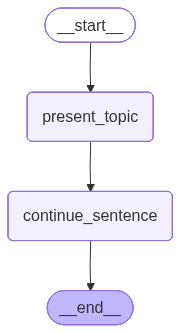

--- present_topic ---
--- continue_sentence ---
{'topic': 'state, nodes, and edges', 'response': 'Today we will study state, nodes, and edges. Nice!'}


In [ ]:
simple_builder = StateGraph(SimpleLessonState)  # create a builder bound to our shared state schema
simple_builder.add_node("present_topic", present_topic)  # register the first node
simple_builder.add_node("continue_sentence", continue_sentence)  # register the second node

simple_builder.add_edge(START, "present_topic")  # execution starts here
simple_builder.add_edge("present_topic", "continue_sentence")  # fixed transition
simple_builder.add_edge("continue_sentence", END)  # stop after the second node

simple_graph = simple_builder.compile()  # validate the builder and create the runnable graph
show_graph(simple_graph)

print(simple_graph.invoke({"topic": "state, nodes, and edges"}))

### Play with the graph

Change the topic below and re-run the cell a few times. This is a good place to see how the same graph structure keeps working even when only the input state changes.


In [ ]:
for topic in [
    "reducers",
    "tool-calling agents",
    "graph-based RAG",
]:
    result = simple_graph.invoke({"topic": topic})
    print(f"Topic: {topic}")
    print(result["response"])
    print("-" * 80)


--- present_topic ---
--- continue_sentence ---
Topic: reducers
Today we will study reducers. You will enjoy!
--------------------------------------------------------------------------------
--- present_topic ---
--- continue_sentence ---
Topic: tool-calling agents
Today we will study tool-calling agents. Learning is fun!
--------------------------------------------------------------------------------
--- present_topic ---
--- continue_sentence ---
Topic: graph-based RAG
Today we will study graph-based RAG. Nice!
--------------------------------------------------------------------------------


### A quick contrast: the same idea as a chain

Before we add routing, it is useful to contrast a graph with a plain chain.

A chain is ideal when the workflow is linear: `input -> prompt -> LLM -> parser`.
A graph becomes more useful when we need branching, loops, memory, tools, or reusable subflows.

Below we will use:

* a structured input object
* a prompt + LLM
* a structured output object

This also anticipates a common LangGraph pattern: use structured outputs inside nodes when the graph needs explicit fields for later decisions.

Official references:

* Thinking in LangGraph: https://docs.langchain.com/oss/python/langgraph/thinking-in-langgraph
* LangChain structured output: https://docs.langchain.com/oss/python/langchain/structured-output


In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

class StructuredOutput(BaseModel):
    company: str = Field(description='Company name')

# Step 2: Prompt Template
prompt = ChatPromptTemplate.from_template(
    "What is a very creative name for a company that makes {product}? Be creative and return a single name."
)

llm2 = llm.with_structured_output(StructuredOutput)

# Define the Chain using | syntax (Runnable style)
chain1 = prompt | llm2

product = "Queen Size Sheet Set"
result = chain1.invoke({"product": product})
print(result)

company='CrownCotton'


# Task

Now, adapt this chain on LangGraph.


In [ ]:
# Answer here

## 10.2 Conditional Routing

So far the graph always followed a fixed path. Conditional routing is the first moment where the graph becomes more than a chain.

The pattern is:

1. one node writes a decision into the state
2. a routing function reads that state
3. the routing function returns a label
4. LangGraph follows the matching conditional edge

In the next example, `classify_question` decides whether the user is asking for a definition or an example. Then the routing function sends execution to the appropriate node.

Two things are worth noticing:

* the routing function does not answer the question; it only chooses where execution should go next
* the returned label must match one of the branches declared in `add_conditional_edges(...)`


In [ ]:
from typing import Literal


class RouteState(TypedDict):
    question: str
    category: str
    answer: str


def classify_question(state: RouteState):
    question = state["question"].lower()
    if "example" in question or "show" in question:
        category = "example"
    else:
        category = "definition"
    return {"category": category}


def route_question(state: RouteState) -> Literal["definition", "example"]:
    if state["category"] == "example":
        return "example"
    return "definition"


def definition_path(state: RouteState):
    return {
        "answer": (
            "A state reducer defines how LangGraph should merge updates when multiple "
            "parts of the graph write to the same key."
        )
    }


def example_path(state: RouteState):
    return {
        "answer": (
            "Example: two parallel reviewer nodes can each return one note, and a reducer "
            "can append both notes into a single list."
        )
    }


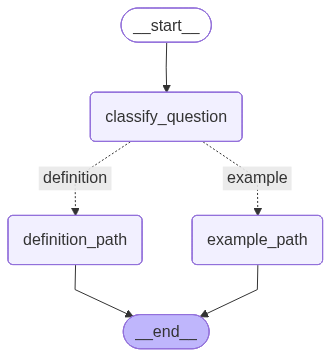

A state reducer defines how LangGraph should merge updates when multiple parts of the graph write to the same key.
---
Example: two parallel reviewer nodes can each return one note, and a reducer can append both notes into a single list.


In [ ]:
route_builder = StateGraph(RouteState)
route_builder.add_node("classify_question", classify_question)
route_builder.add_node("definition_path", definition_path)
route_builder.add_node("example_path", example_path)

route_builder.add_edge(START, "classify_question")
route_builder.add_conditional_edges(
    "classify_question",
    route_question,
    {
        "definition": "definition_path",
        "example": "example_path",
    },
)
route_builder.add_edge("definition_path", END)
route_builder.add_edge("example_path", END)

route_graph = route_builder.compile()
show_graph(route_graph)

print(route_graph.invoke({"question": "What is a state reducer?", "category": "", "answer": ""})["answer"])
print("---")
print(route_graph.invoke({"question": "Show me an example of conditional routing.", "category": "", "answer": ""})["answer"])


### Task

Build a specialist router graph that analyzes each question and sends it to the most appropriate expert node.

You will need:
1. a orquestrator node, that decides to which specialist route the question
2. Two, or more, specilists node, with a specific prompt

In [ ]:
# Your router graph
# Suggested keys: `question`, `route`, `answer`


## 10.3 `MessagesState` and a Tool-Calling Agent - [link](https://docs.langchain.com/oss/python/langgraph/graph-api)

Message-based state is one of the most common patterns in LangGraph. Instead of manually storing conversation turns in a plain list, we can use `MessagesState`, which already includes the `add_messages` reducer under the hood.

That reducer matters because chat history should usually grow over time instead of being overwritten on every step. In other words, `MessagesState` is a convenient prebuilt state for the most common chat pattern.

We will now build a small agent graph with two nodes:

1. `assistant`, which calls the LLM and decides whether a tool is needed
2. `tools`, a prebuilt `ToolNode`, which executes the requested tool call

The graph loops between those nodes until the assistant stops asking for tools and produces a final answer.

Official references:

* Graph API - working with messages and `MessagesState`: https://docs.langchain.com/oss/python/langgraph/graph-api
* Workflows + agents: https://docs.langchain.com/oss/python/langgraph/workflows-agents


In [ ]:

from langchain_core.messages import SystemMessage
from langchain_core.tools import tool
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

@tool
def lesson_lookup(topic: str) -> str:
    """Return a short local glossary entry for a course topic."""
    glossary = {
"state": "The shared data structure that nodes read from and write to.",
"tool node": "A prebuilt node that executes tool calls requested by the assistant.",
"reducer": "A function that merges multiple updates for the same state key.",
    }
    return glossary.get(topic.lower(), "Topic not found in the local glossary.")


@tool
def multiply(a: int, b: int) -> int:
    """Multiply two integers."""
    return a * b


tools = [lesson_lookup, multiply]
llm_with_tools = llm.bind_tools(tools)

system_message = SystemMessage(
    content=(
        "You are a helpful teaching assistant. "
        "Use tools when they are useful. "
        "After receiving a tool result, do not call the same tool again unless necessary. "
        "Use the tool result to write a short final answer to the user."
    )
)


def assistant(state: MessagesState):
    response = llm_with_tools.invoke([system_message] + state["messages"])
    return {"messages": [response]}


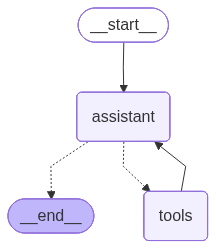

In [ ]:
agent_builder = StateGraph(MessagesState)
agent_builder.add_node("assistant", assistant)
agent_builder.add_node("tools", ToolNode(tools))

agent_builder.add_edge(START, "assistant")
agent_builder.add_conditional_edges("assistant", tools_condition)  # if the model asks for a tool, visit `tools`
agent_builder.add_edge("tools", "assistant")  # after tool execution, let the assistant see the new tool result

agent_graph = agent_builder.compile()
show_graph(agent_graph)


In [ ]:
result = agent_graph.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "I have 4 sections with 3 examples each. How many examples do I have?",
            }
        ]
    }
)

for i, msg in enumerate(result["messages"]):
    print("\n" + "=" * 40)
    print(f"Message {i}: {type(msg).__name__}")
    msg.pretty_print()


Message 0: HumanMessage
================================ Human Message =================================

I have 4 sections with 3 examples each. How many examples do I have?

Message 1: AIMessage
================================== Ai Message ==================================
Tool Calls:
  multiply (chatcmpl-tool-8f1caa0c646455bb)
 Call ID: chatcmpl-tool-8f1caa0c646455bb
  Args:
    a: 4
    b: 3

Message 2: ToolMessage
================================= Tool Message =================================
Name: multiply

12

Message 3: AIMessage
================================== Ai Message ==================================

You have \(4 \times 3 = 12\) examples in total.


### Play with the agent

The two prompts below usually trigger different behaviors: one should lean on the glossary, and the other should call the math tool. Try replacing them with your own prompts.


In [ ]:
agent_prompts = [
    "If I have 6 groups with 7 students each, how many students is that?",
    "What is a tool node? Use the glossary if needed.",
]

for prompt in agent_prompts:
    print("\n" + "=" * 40 + " START " + "=" * 40 + "\n")
    print(f"User: {prompt}")
    result = agent_graph.invoke({"messages": [{"role": "user", "content": prompt}]})
    # result["messages"][-1].pretty_print()
    # print("\n" + "=" * 80 + "\n")

    for i, msg in enumerate(result["messages"]):
        print("\n" + "=" * 40)
        print(f"Message {i}: {type(msg).__name__}")
        msg.pretty_print()
    print("\n" + "=" * 40 + " END " + "=" * 40 + "\n")




========================================START========================================

User: If I have 6 groups with 7 students each, how many students is that?

Message 0: HumanMessage
================================ Human Message =================================

If I have 6 groups with 7 students each, how many students is that?

Message 1: AIMessage
================================== Ai Message ==================================
Tool Calls:
  multiply (chatcmpl-tool-9a6a17dd08f61365)
 Call ID: chatcmpl-tool-9a6a17dd08f61365
  Args:
    a: 6
    b: 7

Message 2: ToolMessage
================================= Tool Message =================================
Name: multiply

42

Message 3: AIMessage
================================== Ai Message ==================================

There are \(6 \times 7 = 42\) students in total.

========================================END========================================


========================================START============================

In [ ]:
for i, msg in enumerate(result["messages"]):
    print("\n" + "=" * 40)
    print(f"Message {i}: {type(msg).__name__}")
    msg.pretty_print()


Message 0: HumanMessage
================================ Human Message =================================

If I have 6 groups with 7 students each, how many students is that?

Message 1: AIMessage
================================== Ai Message ==================================
Tool Calls:
  multiply (functions.multiply:0)
 Call ID: functions.multiply:0
  Args:
    a: 6
    b: 7

Message 2: ToolMessage
================================= Tool Message =================================
Name: multiply

42

Message 3: AIMessage
================================== Ai Message ==================================

 That would be **42 students** total (6 groups × 7 students = 42).


## 10.4 Reducers

Reducers answer a very practical question: **if multiple updates touch the same state key, how should LangGraph combine them?**

By default, a new value returned by a node **overwrites** the previous value of that state key. This is often correct, but not always.

Suppose two nodes both write notes into the same key. Without a reducer, only the most recent update survives. With a reducer, we can append, merge, or otherwise combine updates in a controlled way.

This becomes especially important in two situations:

* when parallel branches write to the same key
* when chat history should accumulate instead of being replaced

In the next two cells, we compare both behaviors side by side.

In [ ]:

class NotesStateNoReducer(TypedDict):
    topic: str
    notes: list[str] # Will LangGraph append to the list?


def note_from_clarity(state: NotesStateNoReducer):
    return {"notes": [f"Clarity note: define {state['topic']} in one sentence."]}


def note_from_practice(state: NotesStateNoReducer):
    return {"notes": [f"Practice note: add one runnable {state['topic']} example."]}


overwrite_builder = StateGraph(NotesStateNoReducer)
overwrite_builder.add_node("first_note", note_from_clarity)
overwrite_builder.add_node("second_note", note_from_practice)
overwrite_builder.add_edge(START, "first_note")
overwrite_builder.add_edge("first_note", "second_note")
overwrite_builder.add_edge("second_note", END)

overwrite_graph = overwrite_builder.compile()
overwrite_graph.invoke({"topic": "LangGraph", "notes": []})["notes"]


['Practice note: add one runnable LangGraph example.']

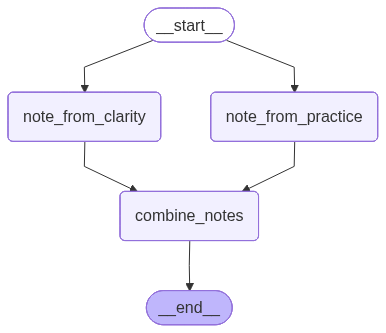

{'topic': 'LangGraph',
 'notes': ['Clarity note: define LangGraph in one sentence.',
  'Practice note: add one runnable LangGraph example.'],
 'summary': '- Clarity note: define LangGraph in one sentence.\n- Practice note: add one runnable LangGraph example.'}

In [ ]:
import operator
from typing import Annotated


class NotesState(TypedDict):
    topic: str
    notes: Annotated[list[str], operator.add] # Now we create a reducer with the add operator
    summary: str


def note_from_clarity(state: NotesState):
    return {"notes": [f"Clarity note: define {state['topic']} in one sentence."]}


def note_from_practice(state: NotesState):
    return {"notes": [f"Practice note: add one runnable {state['topic']} example."]}


def combine_notes(state: NotesState):
    summary = "\n".join(f"- {note}" for note in state["notes"])
    return {"summary": summary}


reducer_builder = StateGraph(NotesState)
reducer_builder.add_node("note_from_clarity", note_from_clarity)
reducer_builder.add_node("note_from_practice", note_from_practice)
reducer_builder.add_node("combine_notes", combine_notes)

reducer_builder.add_edge(START, "note_from_clarity")
reducer_builder.add_edge(START, "note_from_practice")
reducer_builder.add_edge("note_from_clarity", "combine_notes")
reducer_builder.add_edge("note_from_practice", "combine_notes")
reducer_builder.add_edge("combine_notes", END)

reducer_graph = reducer_builder.compile()
show_graph(reducer_graph)

reducer_graph.invoke({"topic": "LangGraph", "notes": [], "summary": ""})


### One more reducer test

Change the topic and compare the output of the overwrite graph with the reducer graph. This makes the merge behavior easier to notice.


In [ ]:
play_topic = "subgraphs"

print("Without reducer:")
print(overwrite_graph.invoke({"topic": play_topic, "notes": []})["notes"])

print("\nWith reducer:")
print(reducer_graph.invoke({"topic": play_topic, "notes": [], "summary": ""})["summary"])


Without reducer:
['Practice note: add one runnable subgraphs example.']

With reducer:
- Clarity note: define subgraphs in one sentence.
- Practice note: add one runnable subgraphs example.


### Connection to `MessagesState`

The `messages` key we used earlier is the same idea with a better reducer. `MessagesState` uses the prebuilt `add_messages` reducer, so chat history grows correctly and existing messages can be updated by id when needed.

So, if you ever find yourself creating a chat state manually, it is often worth asking whether `MessagesState` already gives you the behavior you want.


## 10.5 Short-Term Memory with Checkpointing - [REF](https://docs.langchain.com/oss/python/langgraph/add-memory)

A graph can persist conversation state across turns when compiled with a checkpointer. This is short-term, thread-level memory: the graph remembers earlier state snapshots for the same `thread_id`.

The key idea is simple:

* same `thread_id` -> keep building on the same conversation state
* different `thread_id` -> start a fresh conversation
* the checkpointer stores checkpoints between invocations, so follow-up turns can reuse prior messages

You can save the conversation state using Postgres.

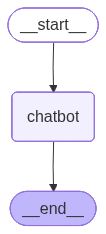

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver


def chatbot_node(state: MessagesState):
    system = SystemMessage(
        content=(
            "You are a concise course assistant. Use the conversation history already "
            "available in the graph state when answering follow-up questions."
        )
    )
    response = llm.invoke([system] + state["messages"])
    return {"messages": [response]}


checkpointer = InMemorySaver()  # in-memory checkpoint store for this notebook session

memory_builder = StateGraph(MessagesState)
memory_builder.add_node("chatbot", chatbot_node)
memory_builder.add_edge(START, "chatbot")

memory_graph = memory_builder.compile(checkpointer=checkpointer)  # memory is enabled here
show_graph(memory_graph)


In [ ]:
config = {"configurable": {"thread_id": "langgraph-course-thread-1"}}

first_turn = memory_graph.invoke(
    {
"messages": [
    {
        "role": "user",
        "content": "My name is Ana and I am reviewing LangGraph today.",
    }
]
    },
    config=config,
)
first_turn["messages"][-1].pretty_print()

print("\n" + "=" * 80 + "\n")

second_turn = memory_graph.invoke(
    {
"messages": [
    {
        "role": "user",
        "content": "What is my name and what topic am I reviewing?",
    }
]
    },
    config=config,
)
second_turn["messages"][-1].pretty_print()


================================== Ai Message ==================================

Nice to meet you, Ana! How can I assist you with LangGraph today?


================================== Ai Message ==================================

Your name is **Ana**, and you’re reviewing **LangGraph**.


### Compare two threads

The first thread already remembers Ana. The second thread starts fresh. Re-run the cell with a new `thread_id` to make the separation visible.


In [ ]:
new_config = {"configurable": {"thread_id": "langgraph-course-thread-2"}}

fresh_turn = memory_graph.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is my name and what topic am I reviewing?",
            }
        ]
    },
    config=new_config,
)

fresh_turn["messages"][-1].pretty_print()


================================== Ai Message ==================================

I don’t have that information yet—could you let me know your name and the topic you’re reviewing?


## 10.6 A First Web Search Graph

Instead of building a mini RAG here, we will build a tiny web research graph. This sets us up for the next notebook, where retrieval becomes a reusable subgraph.

The idea is intentionally simple:

1. `search_web` collects a few search results
2. `summarize_results` turns those raw snippets into a short grounded synthesis

In this Graph, we will first we look at the raw search results, then we see how the model writes a summary from them.

If a `TAVILY_API_KEY` is available, the graph uses live web search.

Official references:

* Tavily search integration: https://docs.langchain.com/oss/python/integrations/tools/tavily_search

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_tavily import TavilySearch


def get_tavily_search_tool(max_results=3):
    if not os.environ.get("TAVILY_API_KEY") and userdata is not None:
        value = userdata.get("TAVILY_API_KEY")
        os.environ["TAVILY_API_KEY"] = value

    return TavilySearch(
        max_results=max_results,
        topic="general",
        include_answer=True,
    )


tavily_search = get_tavily_search_tool(max_results=3)

summary_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful research assistant. Summarize only what is supported by the search results. If the results look weak, say so.",
        ),
        (
            "human",
            "Question: {question}\n\nSearch results:\n{formatted_results}",
        ),
    ]
)


class WebSearchState(TypedDict):
    question: str
    search_results: list[dict]
    summary: str

def search_web(state: WebSearchState):
    raw = tavily_search.invoke({"query": state["question"], "search_depth": "basic"})
    results = raw['results']

    cleaned = []
    for item in results[:3]:
        cleaned.append(
            {
                "title": item.get("title", ""),
                "url": item.get("url", ""),
                "content": item.get("content", ""),
            }
        )
    return {"search_results": cleaned}


def summarize_results(state: WebSearchState):
    formatted_results = "\n\n".join(
        f"Title: {item.get('title', '')}\n"
        f"URL: {item.get('url', '')}\n"
        f"Snippet: {item.get('content', '')}"
        for item in state["search_results"]
    )
    prompt = summary_prompt.invoke(
        {"question": state["question"], "formatted_results": formatted_results}
    )
    response = llm.invoke(prompt)
    return {"summary": response.content}


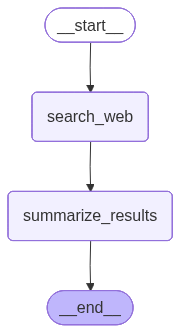

In [ ]:
web_search_builder = StateGraph(WebSearchState)
web_search_builder.add_node("search_web", search_web)
web_search_builder.add_node("summarize_results", summarize_results)
web_search_builder.add_edge(START, "search_web")
web_search_builder.add_edge("search_web", "summarize_results")
web_search_builder.add_edge("summarize_results", END)

web_search_graph = web_search_builder.compile()
show_graph(web_search_graph)


In [ ]:
web_search_result = web_search_graph.invoke(
    {
        "question": "What is LangGraph used for?",
        "search_results": [],
        "summary": "",
    }
)

result = web_search_result

In [ ]:
print("\n## Search Results:")
result['search_results']


## Search Results:


[{'title': 'LangGraph Tutorial: What Is LangGraph and How to Use It? | DataCamp',
  'url': 'https://www.datacamp.com/tutorial/langgraph-tutorial',
  'content': "# LangGraph Tutorial: What Is LangGraph and How to Use It? LangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured and efficient manner. Imagine you're building a complex, multi-agent large language model (LLM) application. It's exciting, but it comes with challenges: managing the state of various agents, coordinating their interactions, and handling errors effectively. LangGraph provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured manner. It simplifies the development process by enabling the creation of cyclical graphs, which are essential for developing agent runtimes. With LangGraph, we can easily build robust, scalable, and flexible multi-agent systems. T

In [ ]:
print("## Question:")
print(result['question'])

print("\n## Search Results:")
print(result['search_results'])

print("\n## Summary:")
print(result['summary'])

## Question:
What is LangGraph used for?

## Search Results:
[{'title': 'LangGraph Tutorial: What Is LangGraph and How to Use It? | DataCamp', 'url': 'https://www.datacamp.com/tutorial/langgraph-tutorial', 'content': "# LangGraph Tutorial: What Is LangGraph and How to Use It? LangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured and efficient manner. Imagine you're building a complex, multi-agent large language model (LLM) application. It's exciting, but it comes with challenges: managing the state of various agents, coordinating their interactions, and handling errors effectively. LangGraph provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured manner. It simplifies the development process by enabling the creation of cyclical graphs, which are essential for developing agent runtimes. With LangGraph, we can easily bu

### Summary

Up to this point, we have already covered the main building blocks that appear repeatedly in LangGraph applications:

* define a state schema
* implement nodes as Python functions
* connect nodes with regular or conditional edges
* use `MessagesState` for chat applications
* add reducers when multiple updates target the same key
* persist thread memory with a checkpointer
* package simple web research workflow as an explicit graph

The most important habit is to make the workflow inspectable. Rather than jumping straight to a big agent, we keep the intermediate state visible: classification labels, accumulated notes, message history, and now raw search results.

# Task 15 - Research, Write, and Revise Essay Agent

Build a graph-based essay agent.

Goal: starting from a user-defined topic or question, the graph should run a small research loop with tools, use that research to write an essay draft, review the draft, and revise it when needed.

Suggested graph flow:

`START -> researcher -> write_essay -> review_essay`

### `researcher`
In this graph, the research stage should behave like a small **research agent** with access to tools. It should:

* search broadly first
* inspect multiple candidate sources
* choose which ones are promising
* extract notes, claims, facts, and useful quotes
* store the URLs or titles of the sources it used

This node should use tools such as:

* `tavily_search`
* `wikipedia_search`
* `open_selected_page` or a similar reading tool

### `write_essay`
Produce a clear essay draft based on the research notes.

It should:
* use the collected notes as grounding
* follow a chosen style or structure
* keep the writing focused on the user request
* incorporate revision feedback when it is called again

### `review_essay`
Check whether the essay is ready.

It should evaluate things like:
* coverage of the topic
* clarity and structure
* grounding in the collected evidence
* missing points or weak reasoning
* whether another revision is needed

If the essay is good enough, the graph can end. Otherwise, it should return to `write_essay` with feedback for revision.

## Possible Graph Diagram:

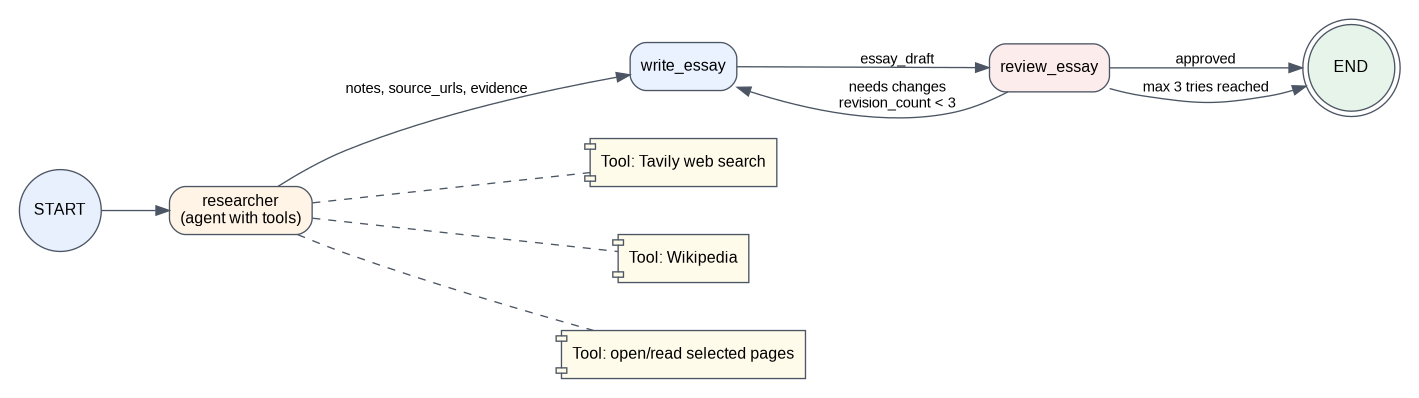